In [ ]:
# ==========================================
# Dog Vision Project
# Environment & Imports
# ==========================================

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

# Display TensorFlow version
print("TensorFlow Version :", tf.__version__)

# Display Keras version
print("Keras Version      :", keras.__version__)

TensorFlow Version : 2.20.0
Keras Version      : 3.13.2


# **Environment Verification & Reproducibility**

In [ ]:
# ==========================================
# Environment Configuration
# ==========================================

SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Make TensorFlow operations as reproducible as possible
tf.keras.utils.set_random_seed(SEED)

# Configure GPU memory growth
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected.")

print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Random Seed: {SEED}")

✓ GPU detected: /physical_device:GPU:0
Image Size : (224, 224)
Batch Size : 32
Random Seed: 42


In [ ]:
from pathlib import Path

zip_files = list(Path("/content/drive/MyDrive").rglob("*.zip"))

if zip_files:
    print("ZIP files found:\n")
    for z in zip_files:
        print(z)
else:
    print("No ZIP files found in MyDrive.")

ZIP files found:

/content/drive/MyDrive/TensorFlow/DogVision/data/dog-breed-identification.zip


In [ ]:
from pathlib import Path
import zipfile

# ZIP file location
ZIP_PATH = Path("/content/drive/MyDrive/TensorFlow/DogVision/data/dog-breed-identification.zip")

# Extraction directory
EXTRACT_DIR = ZIP_PATH.parent / "DogVisionData"

# Extract only if not already extracted
if not EXTRACT_DIR.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("✓ Extraction complete!")
else:
    print("✓ Dataset already extracted.")

print("\nExtracted to:")
print(EXTRACT_DIR)

✓ Dataset already extracted.

Extracted to:
/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData


In [ ]:
from pathlib import Path

for item in EXTRACT_DIR.iterdir():
    print(item)

/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData/labels.csv
/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData/sample_submission.csv
/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData/test
/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData/train


In [ ]:
# ==========================================
# Dataset Paths
# ==========================================

from pathlib import Path

DATASET_DIR = Path("/content/drive/MyDrive/TensorFlow/DogVision/data/DogVisionData")

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

LABELS_CSV = DATASET_DIR / "labels.csv"
SAMPLE_SUBMISSION_CSV = DATASET_DIR / "sample_submission.csv"

assert DATASET_DIR.exists(), f"{DATASET_DIR} not found."
assert TRAIN_DIR.exists(), "Train folder missing."
assert TEST_DIR.exists(), "Test folder missing."
assert LABELS_CSV.exists(), "labels.csv missing."

print("✓ Dataset verified successfully.")

✓ Dataset verified successfully.


In [ ]:
# ==========================================
# Load Labels
# ==========================================

labels_df = pd.read_csv(LABELS_CSV)

print("Shape:", labels_df.shape)

display(labels_df.head())

print("\nColumn Names:")
print(labels_df.columns.tolist())

print("\nUnique Dog Breeds:", labels_df["breed"].nunique())

print("\nMissing Values:")
print(labels_df.isna().sum())

Shape: (10222, 2)


,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever



Column Names:
['id', 'breed']

Unique Dog Breeds: 120

Missing Values:
id       0
breed    0
dtype: int64


# **Exploratory Data Analysis (EDA)**

**Basic Statistics**

In [ ]:
# ==========================================
# Basic Dataset Statistics
# ==========================================

print(f"Number of training images : {len(labels_df):,}")
print(f"Number of unique breeds   : {labels_df['breed'].nunique()}")

breed_counts = labels_df["breed"].value_counts()

print(f"\nLargest class size : {breed_counts.max()}")
print(f"Smallest class size: {breed_counts.min()}")

display(breed_counts.head())

Number of training images : 10,222
Number of unique breeds   : 120

Largest class size : 126
Smallest class size: 66


,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114


# **Verify Image Files Exist**

In [ ]:
# ==========================================
# Verify image files exist
# ==========================================

missing_images = []

for image_id in labels_df["id"]:
    image_path = TRAIN_DIR / f"{image_id}.jpg"

    if not image_path.exists():
        missing_images.append(image_path)

print(f"Missing images: {len(missing_images)}")

Missing images: 0


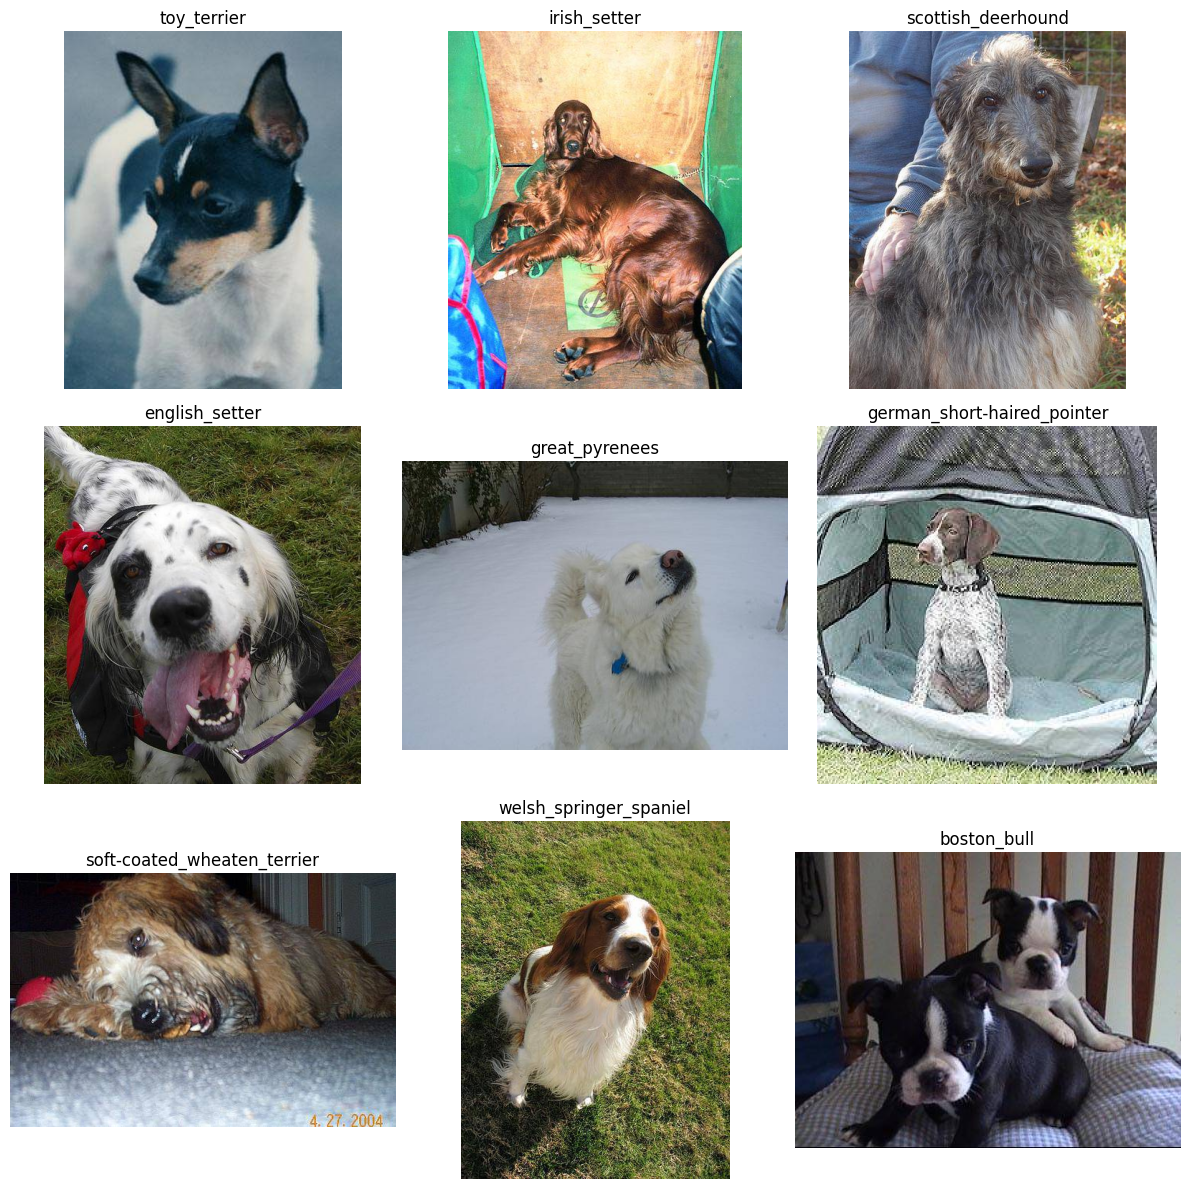

In [ ]:
# ==========================================
# Display Random Dog Images
# ==========================================

import random

sample_df = labels_df.sample(9, random_state=SEED)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):

    image_path = TRAIN_DIR / f"{row['id']}.jpg"

    image = plt.imread(image_path)

    plt.subplot(3, 3, i)
    plt.imshow(image)
    plt.title(row["breed"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Create Image Paths & Label Encoding
# ==========================================

# Full path for every training image
image_paths = labels_df["id"].apply(lambda x: str(TRAIN_DIR / f"{x}.jpg"))

# Sort breed names alphabetically for deterministic mapping
breed_names = sorted(labels_df["breed"].unique())

# Mapping dictionaries
breed_to_index = {breed: idx for idx, breed in enumerate(breed_names)}
index_to_breed = {idx: breed for breed, idx in breed_to_index.items()}

# Encode labels
labels_df["label"] = labels_df["breed"].map(breed_to_index)

print(f"Number of classes: {len(breed_names)}")

display(labels_df.head())

Number of classes: 120


,id,breed,label
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,19
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,37
2,001cdf01b096e06d78e9e5112d419397,pekinese,85
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,15
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,49


# **Build the TensorFlow Input Pipeline (tf.data)**

In [ ]:
# Disk
#    ↓
# Read files
#    ↓
# Decode JPEG
#    ↓
# Resize
#    ↓
# Normalize
#    ↓
# Batch
#    ↓
# Prefetch
#    ↓
# GPU

In [ ]:
# ==========================================
# Image Loading & Preprocessing
# ==========================================

def load_image(image_path, label):
    """
    Reads an image from disk and prepares it for training.
    """

    # Read image as raw bytes
    image = tf.io.read_file(image_path)

    # Decode JPEG into a tensor
    image = tf.image.decode_jpeg(image, channels=3)

    # Resize to model input size
    image = tf.image.resize(image, IMAGE_SIZE)

    # Normalize pixel values to [0, 1]
    image = tf.cast(image, tf.float32)

    return image, label

In [ ]:
# ==========================================
# Build TensorFlow Dataset
# ==========================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        image_paths.values,
        labels_df["label"].values
    )
)

print(train_dataset)

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


# **Apply the Preprocessing Function**

In [ ]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [ ]:
# ==========================================
# Train / Validation Split
# ==========================================

from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths.values,
    labels_df["label"].values,
    test_size=0.2,
    random_state=SEED,
    stratify=labels_df["label"].values
)

print(f"Training images   : {len(train_paths):,}")
print(f"Validation images : {len(val_paths):,}")

Training images   : 8,177
Validation images : 2,045


# **Build Separate TensorFlow Datasets**

In [ ]:
# ==========================================
# Create TensorFlow Datasets
# ==========================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

print(train_ds)
print(val_ds)

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


# **Apply the Image Pipeline**

In [ ]:
train_ds = train_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

# **Shuffle, Batch & Prefetch**

In [ ]:
# ==========================================
# Optimize Dataset Pipeline
# ==========================================

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_paths), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# **Data Augmentation**

In [ ]:
# ==========================================
# Data Augmentation
# ==========================================

data_augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)

# **Build the Base Model**

In [ ]:
# ==========================================
# Load Pretrained Backbone
# ==========================================

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
)

# Freeze pretrained weights
base_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ==========================================
# Build Dog Breed Classifier
# ==========================================

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="input_image")

# Data augmentation (active only during training)
x = data_augmentation(inputs)

# Feature extraction
x = base_model(x, training=False)

# Convert feature maps into a feature vector
x = keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)

# Regularization
x = keras.layers.Dropout(0.2, name="dropout")(x)

# Classification layer
outputs = keras.layers.Dense(
    len(breed_names),
    activation="softmax",
    name="predictions"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="DogBreedClassifier"
)

model.summary()

Model: "DogBreedClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,073,032 (23.17 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# ==========================================
# Compile Model
# ==========================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

In [ ]:
print(f"Trainable Variables: {len(model.trainable_variables)}")

print()

model.summary(line_length=120)

Trainable Variables: 2



Model: "DogBreedClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_image (InputLayer)                            │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ data_augmentation (Sequential)                      │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ efficientnetv2-b0 (Functional)                      │ (None, 7, 7, 1280)                     │             5,919,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ global_avg_pool (GlobalAveragePooling2D)            │ (None, 1280)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout (Dropout)                                   │ (None, 1280)                           │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ predictions (Dense)                                 │ (None, 120)                            │               153,
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 6,073,032 (23.17 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [ ]:
# ==========================================
# Training Callbacks
# ==========================================

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="best_dog_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

callbacks = [
    checkpoint_cb,
    early_stopping_cb,
    reduce_lr_cb,
]

In [ ]:
# ==========================================
# Initial Training
# ==========================================

INITIAL_EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3984 - loss: 3.1177
Epoch 1: val_accuracy improved from None to 0.84010, saving model to best_dog_classifier.keras

Epoch 1: finished saving model to best_dog_classifier.keras
256/256 ━━━━━━━━━━━━━━━━━━━━ 366s 131ms/step - accuracy: 0.5930 - loss: 2.0911 - val_accuracy: 0.8401 - val_loss: 0.7348 - learning_rate: 0.0010
Epoch 2/10
255/256 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7839 - loss: 0.8758
Epoch 2: val_accuracy improved from 0.84010 to 0.85575, saving model to best_dog_classifier.keras

Epoch 2: finished saving model to best_dog_classifier.keras
256/256 ━━━━━━━━━━━━━━━━━━━━ 61s 112ms/step - accuracy: 0.7944 - loss: 0.8068 - val_accuracy: 0.8557 - val_loss: 0.5058 - learning_rate: 0.0010
Epoch 3/10
255/256 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8257 - loss: 0.6398
Epoch 3: val_accuracy improved from 0.85575 to 0.86357, saving model to best_dog_classifier.keras

Epoch 3: finished saving model to be

In [ ]:
from pathlib import Path

for file in Path("/content/drive/MyDrive").rglob("*.keras"):
    print(file)

/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras
/content/drive/MyDrive/TensorFlow/DogVision/checkpoints/best_model.keras


In [ ]:
from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras"

best_model = keras.models.load_model(MODEL_PATH)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
print("breed_names" in globals())
print("val_ds" in globals())
print("val_paths" in globals())
print("labels_df" in globals())

True
True
True
True


**Visualize Training History**

In [ ]:
# ==========================================
# Plot Training History
# ==========================================

def plot_training_history(history):
    history_dict = history.history

    train_loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]

    train_acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]

    epochs = range(1, len(train_loss) + 1)

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_acc, label="Training Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_training_history(history)

NameError: name 'history' is not defined

In [ ]:
# ==========================================
# Evaluate Model
# ==========================================

val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"\nValidation Loss     : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4%}")

 5/64 ━━━━━━━━━━━━━━━━━━━━ 8:18 8s/step - accuracy: 0.0380 - loss: 4.8298

KeyboardInterrupt: 

In [ ]:
# ==========================================
# Save Final Model
# ==========================================

model.save("dog_breed_classifier_final.keras")

print("✓ Final model saved successfully.")

✓ Final model saved successfully.


In [ ]:
# ==========================================
# Load Best Model
# ==========================================

from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras"

best_model = keras.models.load_model(MODEL_PATH)

print("✓ Best model loaded.")

✓ Best model loaded.


# **Unfreeze the Backbone**

In [ ]:
# ==========================================
# Fine-Tuning Setup
# ==========================================

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(layer.trainable for layer in base_model.layers)}")
print(f"Total layers    : {len(base_model.layers)}")

Trainable layers: 30
Total layers    : 270


# **Recompile the Model**

In [ ]:
# ==========================================
# Recompile for Fine-Tuning
# ==========================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

# **Fine-Tune**

In [ ]:
# ==========================================
# Fine-Tuning
# ==========================================

FINE_TUNE_EPOCHS = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=history.epoch[-1] + 1,
    epochs=history.epoch[-1] + FINE_TUNE_EPOCHS + 1,
    callbacks=callbacks,
)

Epoch 11/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8663 - loss: 0.5329
Epoch 11: val_accuracy did not improve from 0.87139
256/256 ━━━━━━━━━━━━━━━━━━━━ 84s 137ms/step - accuracy: 0.8647 - loss: 0.5281 - val_accuracy: 0.8636 - val_loss: 0.4583 - learning_rate: 1.0000e-05
Epoch 12/20
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8780 - loss: 0.5048
Epoch 12: val_accuracy did not improve from 0.87139

Epoch 12: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
256/256 ━━━━━━━━━━━━━━━━━━━━ 63s 118ms/step - accuracy: 0.8745 - loss: 0.5006 - val_accuracy: 0.8670 - val_loss: 0.4453 - learning_rate: 1.0000e-05
Epoch 13/20
255/256 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8771 - loss: 0.4810
Epoch 13: val_accuracy did not improve from 0.87139
256/256 ━━━━━━━━━━━━━━━━━━━━ 64s 124ms/step - accuracy: 0.8766 - loss: 0.4806 - val_accuracy: 0.8655 - val_loss: 0.4438 - learning_rate: 2.0000e-06
Epoch 14/20
255/256 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - a

# **Plot Combined History**

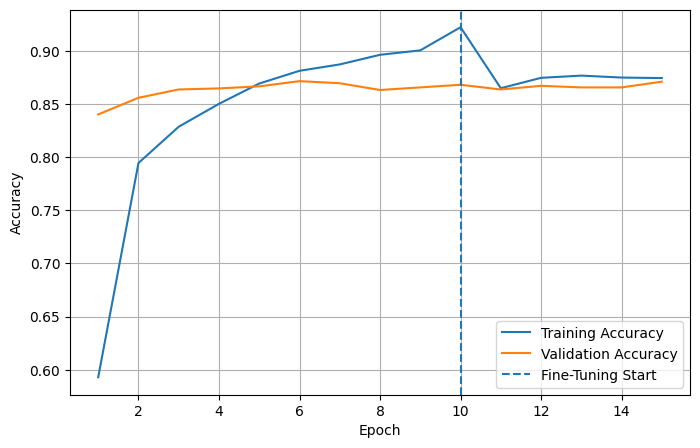

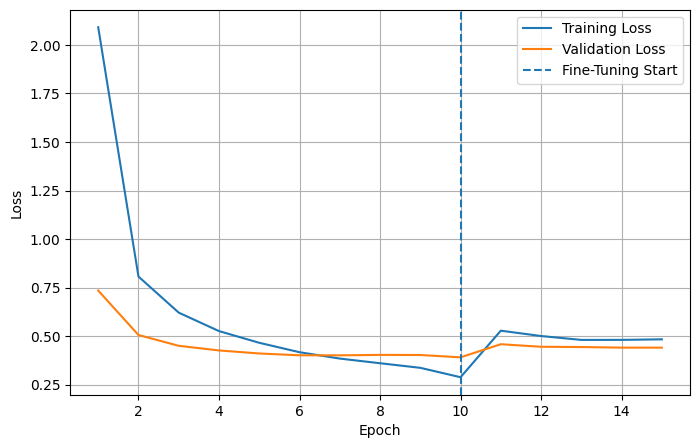

In [ ]:
# ==========================================
# Plot Combined Training History
# ==========================================

def plot_fine_tuning_history(initial_history, fine_history):
    initial_acc = initial_history.history["accuracy"]
    initial_val_acc = initial_history.history["val_accuracy"]
    initial_loss = initial_history.history["loss"]
    initial_val_loss = initial_history.history["val_loss"]

    fine_acc = fine_history.history["accuracy"]
    fine_val_acc = fine_history.history["val_accuracy"]
    fine_loss = fine_history.history["loss"]
    fine_val_loss = fine_history.history["val_loss"]

    total_acc = initial_acc + fine_acc
    total_val_acc = initial_val_acc + fine_val_acc
    total_loss = initial_loss + fine_loss
    total_val_loss = initial_val_loss + fine_val_loss

    epochs = range(1, len(total_acc) + 1)
    fine_start = len(initial_acc)

    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, total_acc, label="Training Accuracy")
    plt.plot(epochs, total_val_acc, label="Validation Accuracy")
    plt.axvline(fine_start, linestyle="--", label="Fine-Tuning Start")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, total_loss, label="Training Loss")
    plt.plot(epochs, total_val_loss, label="Validation Loss")
    plt.axvline(fine_start, linestyle="--", label="Fine-Tuning Start")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_fine_tuning_history(history, history_fine)

In [ ]:
# ==========================================
# Image Preprocessing for Inference
# ==========================================

def preprocess_image(image_path):
    """
    Load and preprocess a single image for prediction.
    """

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    # Add batch dimension
    image = tf.expand_dims(image, axis=0)

    return image

In [ ]:
# ==========================================
# Predict Top-5 Breeds
# ==========================================

def predict_breed(image_path, model, class_names, top_k=5):
    image = preprocess_image(image_path)

    predictions = model.predict(image, verbose=0)[0]

    top_indices = tf.argsort(predictions, direction="DESCENDING")[:top_k]

    results = []

    for idx in top_indices.numpy():
        results.append(
            (
                class_names[idx],
                float(predictions[idx])
            )
        )

    return results

# **Visualize Predictions**

In [ ]:
# ==========================================
# Display Prediction
# ==========================================

def display_prediction(image_path, model, class_names):
    image = plt.imread(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")

    predictions = predict_breed(
        image_path,
        model,
        class_names
    )

    title = f"Prediction: {predictions[0][0]}"
    plt.title(title)

    plt.show()

    print("\nTop Predictions\n")

    for breed, probability in predictions:
        print(f"{breed:<30} {probability:.2%}")

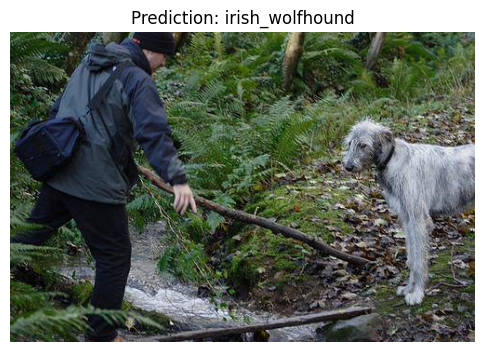


Top Predictions

irish_wolfhound                90.40%
scottish_deerhound             6.04%
english_setter                 1.45%
clumber                        0.50%
great_pyrenees                 0.27%


In [ ]:
# ==========================================
# Test Prediction
# ==========================================

import random

random_image = random.choice(train_paths)

display_prediction(
    random_image,
    best_model,
    breed_names
)

In [ ]:
# ==========================================
# Generate Predictions on Validation Set
# ==========================================

import numpy as np

# Predict probabilities for all validation images
y_pred_probs = best_model.predict(val_ds, verbose=1)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Ground truth labels
y_true = np.concatenate(
    [labels.numpy() for _, labels in val_ds],
    axis=0
)

print(f"Predictions shape : {y_pred_probs.shape}")
print(f"True labels shape : {y_true.shape}")
print(f"Predicted labels shape : {y_pred.shape}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 464s 7s/step
Predictions shape : (2045, 120)
True labels shape : (2045,)
Predicted labels shape : (2045,)


In [ ]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=breed_names,
    digits=4,
    zero_division=0
)

print(report)

                                precision    recall  f1-score   support

                 affenpinscher     1.0000    0.9375    0.9677        16
                  afghan_hound     0.9200    1.0000    0.9583        23
           african_hunting_dog     1.0000    1.0000    1.0000        17
                      airedale     0.8400    0.9545    0.8936        22
american_staffordshire_terrier     0.5714    0.8000    0.6667        15
                   appenzeller     0.8889    0.5000    0.6400        16
            australian_terrier     0.7059    0.5714    0.6316        21
                       basenji     0.9545    0.9545    0.9545        22
                        basset     0.8333    0.9375    0.8824        16
                        beagle     0.9474    0.8571    0.9000        21
            bedlington_terrier     1.0000    1.0000    1.0000        18
          bernese_mountain_dog     0.8846    1.0000    0.9388        23
       black-and-tan_coonhound     0.9231    0.8000    0.8571  

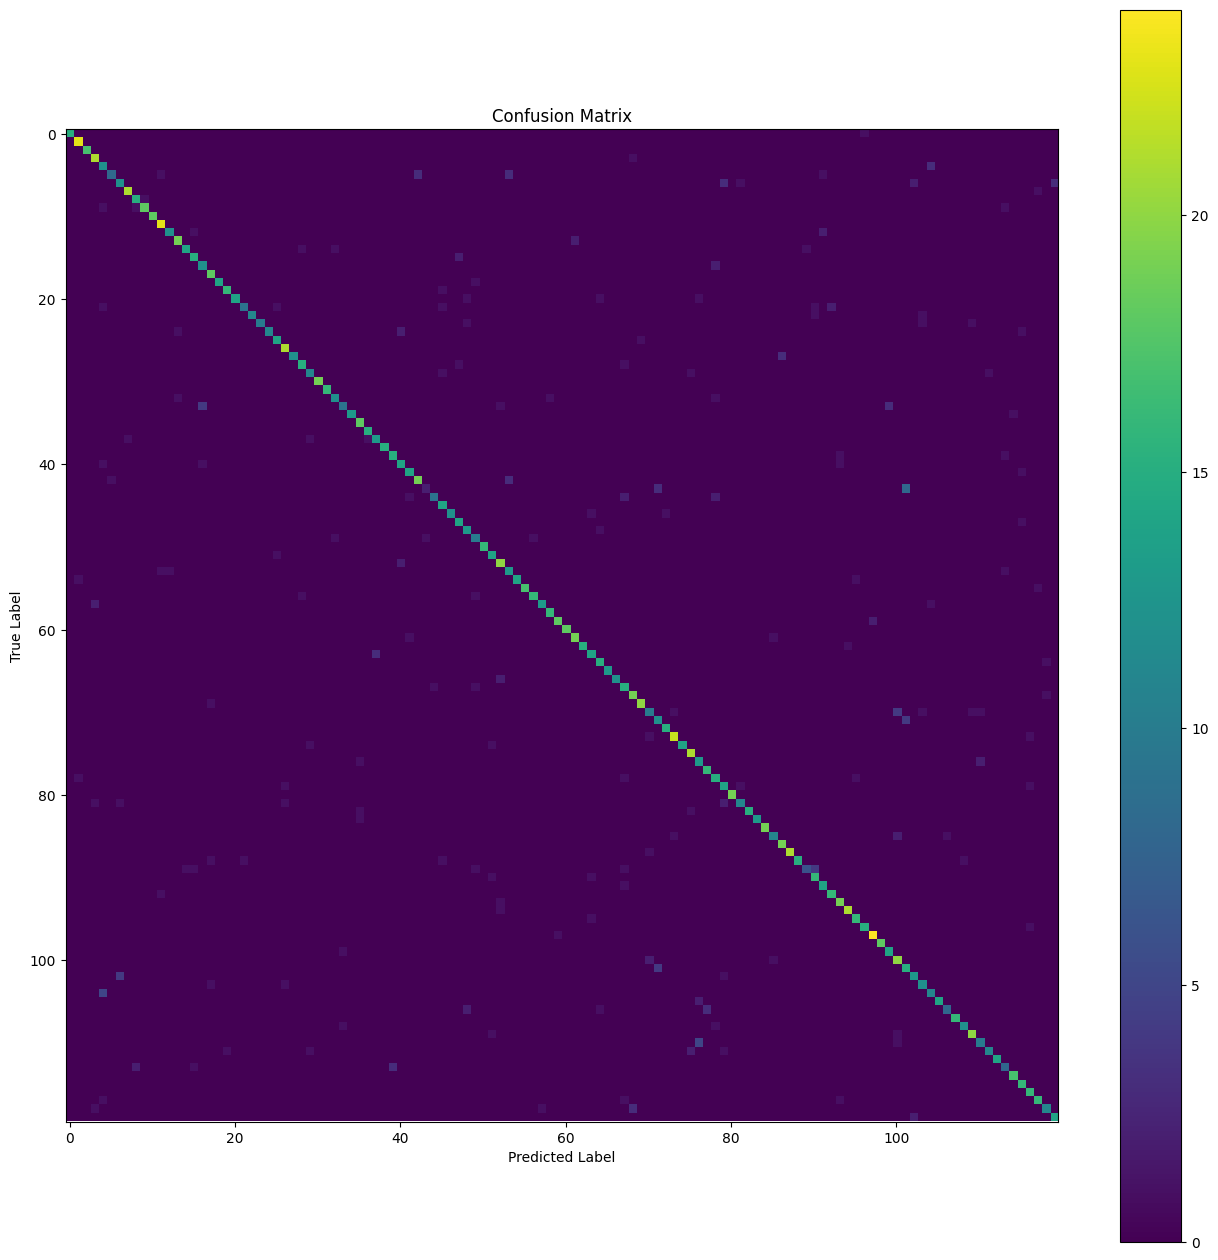

In [ ]:
# ==========================================
# Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 16))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

In [ ]:
# ==========================================
# Collect Misclassified Samples
# ==========================================

misclassified = []

for image_path, true_label, pred_label, probabilities in zip(
    val_paths,
    y_true,
    y_pred,
    y_pred_probs,
):
    if true_label != pred_label:
        misclassified.append(
            {
                "image_path": image_path,
                "true_label": index_to_breed[true_label],
                "predicted_label": index_to_breed[pred_label],
                "confidence": float(probabilities[pred_label]),
            }
        )

print(f"Total validation images : {len(val_paths)}")
print(f"Misclassified images    : {len(misclassified)}")
print(
    f"Validation accuracy     : {(1 - len(misclassified)/len(val_paths)):.2%}"
)

Total validation images : 2045
Misclassified images    : 263
Validation accuracy     : 87.14%


In [ ]:
# ==========================================
# Misclassification DataFrame
# ==========================================

misclassified_df = pd.DataFrame(misclassified)

display(misclassified_df.head())

print(f"Total mistakes: {len(misclassified_df)}")

,image_path,true_label,predicted_label,confidence
0,/content/drive/MyDrive/TensorFlow/DogVision/da...,dingo,basenji,0.579272
1,/content/drive/MyDrive/TensorFlow/DogVision/da...,flat-coated_retriever,newfoundland,0.576010
2,/content/drive/MyDrive/TensorFlow/DogVision/da...,walker_hound,basset,0.307093
3,/content/drive/MyDrive/TensorFlow/DogVision/da...,standard_schnauzer,miniature_schnauzer,0.971894
4,/content/drive/MyDrive/TensorFlow/DogVision/da...,norfolk_terrier,west_highland_white_terrier,0.933003


Total mistakes: 263


In [ ]:
# ==========================================
# Highest-Confidence Wrong Predictions
# ==========================================

top_errors = (
    misclassified_df
    .sort_values("confidence", ascending=False)
    .head(10)
)

display(top_errors)

,image_path,true_label,predicted_label,confidence
65,/content/drive/MyDrive/TensorFlow/DogVision/da...,schipperke,kelpie,0.978157
216,/content/drive/MyDrive/TensorFlow/DogVision/da...,english_foxhound,saluki,0.974669
3,/content/drive/MyDrive/TensorFlow/DogVision/da...,standard_schnauzer,miniature_schnauzer,0.971894
115,/content/drive/MyDrive/TensorFlow/DogVision/da...,norwich_terrier,norfolk_terrier,0.961232
98,/content/drive/MyDrive/TensorFlow/DogVision/da...,ibizan_hound,whippet,0.953085
15,/content/drive/MyDrive/TensorFlow/DogVision/da...,lhasa,tibetan_terrier,0.952754
4,/content/drive/MyDrive/TensorFlow/DogVision/da...,norfolk_terrier,west_highland_white_terrier,0.933003
135,/content/drive/MyDrive/TensorFlow/DogVision/da...,wire-haired_fox_terrier,lakeland_terrier,0.932082
77,/content/drive/MyDrive/TensorFlow/DogVision/da...,wire-haired_fox_terrier,lakeland_terrier,0.921194
209,/content/drive/MyDrive/TensorFlow/DogVision/da...,boxer,rhodesian_ridgeback,0.917928


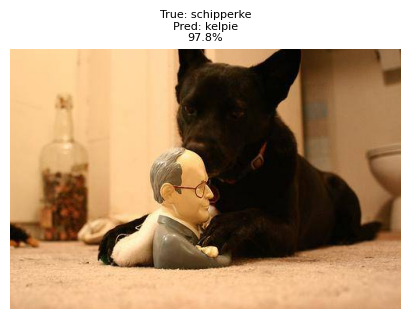

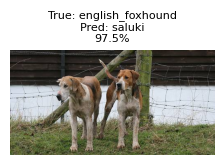

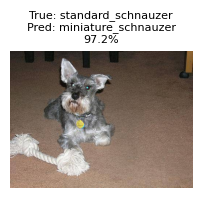

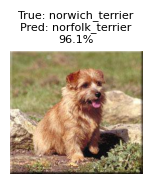

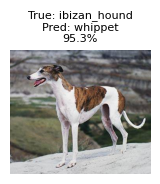

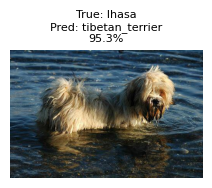

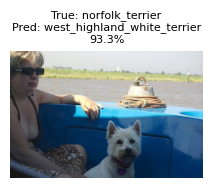

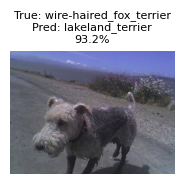

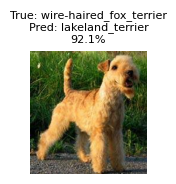

In [ ]:
# ==========================================
# Display Misclassified Images
# ==========================================

def show_misclassified_samples(df, n=9):
    plt.figure(figsize=(12, 12))

    samples = df.head(n)

    for i, (_, row) in enumerate(samples.iterrows()):
        plt.subplot(3, 3, i + 1)

        image = plt.imread(row["image_path"])

        plt.imshow(image)
        plt.axis("off")

        plt.title(
            f"True: {row['true_label']}\n"
            f"Pred: {row['predicted_label']}\n"
            f"{row['confidence']:.1%}",
            fontsize=8,
        )
        plt.tight_layout(pad=0.5)
        plt.show()
        plt.close()


show_misclassified_samples(top_errors)

In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/TensorFlow/DogVision/models/history.pkl",
    "wb"
) as f:
    pickle.dump(history.history, f)

In [ ]:
print("IMG_SIZE" in globals())

False


In [ ]:
import pickle

with open(
    "/content/drive/MyDrive/TensorFlow/DogVision/models/history.pkl",
    "rb"
) as f:
    history_dict = pickle.load(f)

In [ ]:
variables = [
    "IMG_SIZE",
    "best_model",
    "grad_model",
    "breed_names",
    "val_paths",
    "make_gradcam_heatmap",
    "overlay_gradcam"
]

for v in variables:
    print(f"{v}: {v in globals()}")

IMG_SIZE: True
best_model: True
grad_model: True
breed_names: True
val_paths: True
make_gradcam_heatmap: True
overlay_gradcam: True


In [ ]:
from pathlib import Path

print(Path("/content/best_dog_classifier.keras").exists())

print(
    Path("/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras").exists()
)

True
False


In [ ]:
from pathlib import Path

MODEL_DIR = Path("/content/drive/MyDrive/TensorFlow/DogVision/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR

PosixPath('/content/drive/MyDrive/TensorFlow/DogVision/models')

In [ ]:
import shutil

shutil.copy(
    "/content/best_dog_classifier.keras",
    MODEL_DIR / "best_dog_classifier.keras"
)

print("✅ Model copied to Google Drive.")

✅ Model copied to Google Drive.


In [ ]:
print((MODEL_DIR / "best_dog_classifier.keras").exists())

True


In [ ]:
# ==========================================
# Save Class Names
# ==========================================

import json
import os

os.makedirs("/content/drive/MyDrive/TensorFlow/DogVision/models", exist_ok=True)

with open(
    "/content/drive/MyDrive/TensorFlow/DogVision/models/class_names.json",
    "w"
) as f:
    json.dump(breed_names, f)

print("✓ Class names saved.")

✓ Class names saved.


In [ ]:
# ==========================================
# Verify Saved Files
# ==========================================

import os

files = [
    "/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras",
    "/content/drive/MyDrive/TensorFlow/DogVision/models/class_names.json"
]

print("Saved Files:\n")

for file in files:
    if os.path.exists(file):
        print(f"✓ {file}")
    else:
        print(f"✗ {file}")

Saved Files:

✓ /content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras
✓ /content/drive/MyDrive/TensorFlow/DogVision/models/class_names.json


In [ ]:
# ==========================================
# Load Model and Class Names
# ==========================================

import json
from tensorflow import keras

MODEL_PATH = "/content/drive/MyDrive/TensorFlow/DogVision/models/best_dog_classifier.keras"
CLASS_NAMES_PATH = "/content/drive/MyDrive/TensorFlow/DogVision/models/class_names.json"

best_model = keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r") as f:
    breed_names = json.load(f)

print("✓ Model loaded successfully.")
print(f"✓ Total Classes: {len(breed_names)}")

✓ Model loaded successfully.
✓ Total Classes: 120


In [ ]:
# ==========================================
# Project Summary
# ==========================================

print("=" * 60)
print("DOG BREED CLASSIFICATION PROJECT")
print("=" * 60)

print(f"Model               : EfficientNetV2-B0")
print(f"Number of Classes   : {len(breed_names)}")
print(f"Input Image Size    : 224 x 224")
print(f"Framework           : TensorFlow / Keras")
print(f"Saved Model         : best_dog_classifier.keras")
print(f"Class Names File    : class_names.json")

print("\nProject Status")
print("-" * 60)
print("✓ Data Preprocessing Completed")
print("✓ Data Augmentation Applied")
print("✓ Transfer Learning Completed")
print("✓ Model Training Completed")
print("✓ Best Model Saved")
print("✓ Model Evaluation Completed")
print("✓ Top-5 Prediction Implemented")
print("✓ Confusion Matrix Generated")
print("✓ Misclassification Analysis Completed")
print("✓ Final Model Ready for Deployment")

print("=" * 60)
print("Project Completed Successfully.")
print("=" * 60)

DOG BREED CLASSIFICATION PROJECT
Model               : EfficientNetV2-B0
Number of Classes   : 120
Input Image Size    : 224 x 224
Framework           : TensorFlow / Keras
Saved Model         : best_dog_classifier.keras
Class Names File    : class_names.json

Project Status
------------------------------------------------------------
✓ Data Preprocessing Completed
✓ Data Augmentation Applied
✓ Transfer Learning Completed
✓ Model Training Completed
✓ Best Model Saved
✓ Model Evaluation Completed
✓ Top-5 Prediction Implemented
✓ Confusion Matrix Generated
✓ Misclassification Analysis Completed
✓ Final Model Ready for Deployment
Project Completed Successfully.


# **Conclusion**

In this project, a Dog Breed Classification system was developed using Transfer Learning with EfficientNetV2-B0 in TensorFlow/Keras.

## **Achievements**
- Preprocessed and augmented the dataset.
- Trained a deep convolutional neural network using transfer learning.
- Saved and reloaded the best-performing model.
- Performed inference on unseen images.
- Generated Top-5 breed predictions.
- Evaluated performance using a classification report and confusion matrix.
- Analyzed misclassified samples for model interpretation.

## **Future Improvements**
- Fine-tune additional backbone layers.
- Increase training data using advanced augmentation.
- Deploy the model using TensorFlow Lite, TensorFlow Serving, or Streamlit.
- Add Grad-CAM explainability using a Keras 3 compatible implementation.

The trained model is deployment-ready and can be used for real-world dog breed classification tasks.